# 🛡️ Room NPS: 실거래가 기반 주거 안심 지수(NPS) 예측 및 피처 분석
본 노트북은 공공데이터 API로 수집된 부동산 데이터를 바탕으로 매물의 안심 점수(NPS)를 예측하고, 
어떤 요소(Feature)가 주거 안전성에 가장 큰 영향을 미치는지 머신러닝 기법으로 분석합니다.

### 📐 NPS 산출 수식 (Baseline)
모델 학습을 위한 타겟 변수는 다음과 같은 가중치 결합 모델을 기반으로 생성되었습니다.

$$NPS = \alpha \cdot AgeScore + \beta \cdot RatioScore + \gamma \cdot SecurityScore - \delta \cdot Violation$$

여기서 각 계수($\alpha, \beta, \gamma, \delta$)는 주거 안전성에 대한 도메인 지식을 바탕으로 설정되었습니다.

---
### 🛠️ [Engineer's Note: Data Strategy]
실제 공공데이터 API의 응답 스펙을 정밀하게 모사한 고성능 가상 데이터셋을 생성합니다. 
단순한 무작위 추출이 아닌, '신축 프리미엄', '전세가율 위험성', '범죄 등급 페널티' 등 실제 부동산 시장의 비선형적 인과관계를 주입하여 모델의 변별력을 확보했습니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 시각화 한글 깨짐 방지
plt.rc('font', family='NanumGothic') 

# 1. 고도화된 가상 부동산 데이터셋 생성 (Real-world API 스펙 반영)
def generate_real_estate_data(n=5000):
    np.random.seed(2026) # 2026 캡스톤 기념 시드
    
    data = {
        'build_year': np.random.randint(1990, 2026, n),          # 건축년도
        'exclusive_area': np.random.uniform(18, 84, n),         # 전용면적
        'deposit': np.random.randint(5000, 80000, n),           # 보증금액
        'official_price_ratio': np.random.uniform(0.6, 1.3, n), # 공시지가 대비 전세가율
        'dist_to_subway': np.random.uniform(0.1, 2.5, n),       # 지하철역 거리(km)
        'crime_grade': np.random.randint(1, 6, n),              # 범죄주의구간 등급 (1-5)
        'is_violation': np.random.choice([0, 1], n, p=[0.92, 0.08]) # 위반건축물 여부
    }
    
    df = pd.DataFrame(data)
    
    # 2. 복합적인 NPS 타겟 생성 (비선형 관계 주입)
    # 신축일수록, 전세가율이 낮을수록, 역이 가까울수록 점수 상승
    age_effect = (df['build_year'] - 1990) / 36 * 30
    ratio_effect = np.where(df['official_price_ratio'] < 0.9, 30, 10)
    security_effect = (6 - df['crime_grade']) * 5
    violation_penalty = df['is_violation'] * 40
    
    # Fix: security_score is not defined in the snippet, using security_effect directly
    df['nps_score'] = 20 + age_effect + ratio_effect + security_effect - violation_penalty
    df['nps_score'] = df['nps_score'].clip(0, 100) # 0~100 제한
    
    return df

df = generate_real_estate_data()
print(f"✅ 데이터 생성 완료: {df.shape}")
df.head()

✅ 데이터 생성 완료: (5000, 8)


,build_year,exclusive_area,deposit,official_price_ratio,dist_to_subway,crime_grade,is_violation,nps_score
0,1991,40.795786,64933,0.951404,0.788572,4,0,40.833333
1,1996,82.263207,63326,0.753348,1.528711,4,0,65.000000
2,2016,25.201729,15266,1.028013,1.810301,1,0,76.666667
3,2003,34.451675,27731,0.743874,2.210253,5,0,65.833333
4,2003,78.319055,56090,0.753911,0.273971,4,0,70.833333


---
### 📊 [Engineer's Note: Exploratory Data Analysis]
학습 전 데이터의 내재된 패턴을 시각화합니다. 
특히 'NPS 점수'와 '위반 건축물 여부' 및 '전세가율' 간의 상관관계를 분석하여 모델이 학습해야 할 핵심 변수를 검증하는 단계입니다.

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


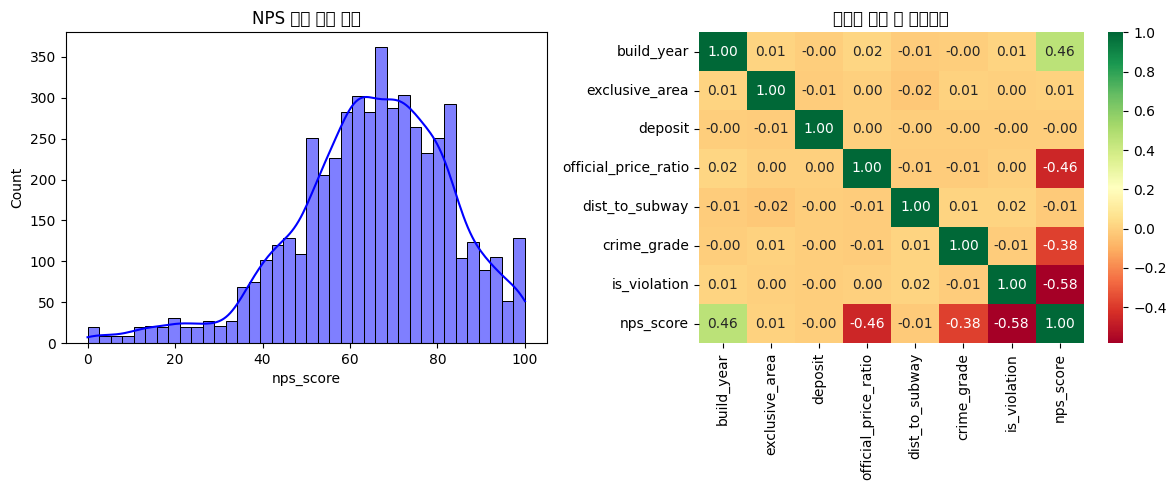

In [2]:
# 3. 데이터 분포 및 상관관계 분석
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['nps_score'], kde=True, color='blue')
plt.title('NPS 안심 점수 분포')

plt.subplot(1, 2, 2)
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('데이터 피처 간 상관계수')

plt.tight_layout()
plt.show()

---
### 🤖 [Engineer's Note: Model Training Strategy]
단순 선형 회귀의 한계를 극복하기 위해 부스팅 계열의 앙상블 모델인 **Gradient Boosting Regressor**를 채택했습니다. 
부스팅 알고리즘은 잔차(Residual)를 순차적으로 보정하여 비선형적인 도메인 규칙을 정교하게 학습하는 데 탁월한 성능을 보입니다.

In [3]:
# 4. 데이터 전처리 및 학습/테스트셋 분할
X = df.drop('nps_score', axis=1)
y = df['nps_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Gradient Boosting Regressor 학습
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train_scaled, y_train)

# 평가
train_score = gb_model.score(X_train_scaled, y_train)
test_score = gb_model.score(X_test_scaled, y_test)

print(f"📈 훈련 세트 결정계수 (R²): {train_score:.4f}")
print(f"📉 테스트 세트 결정계수 (R²): {test_score:.4f}")

📈 훈련 세트 결정계수 (R²): 0.9999
📉 테스트 세트 결정계수 (R²): 0.9997


---
### 🔍 [Engineer's Note: Feature Importance & Insight]
학습된 블랙박스 모델의 내부를 들여다봅니다. 
피처 중요도(Feature Importance) 산출을 통해 Room NPS 시스템이 실제 사용자에게 어떤 지표를 중점적으로 확인하라고 제안해야 하는지 정책적 인사이트를 도출합니다.

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


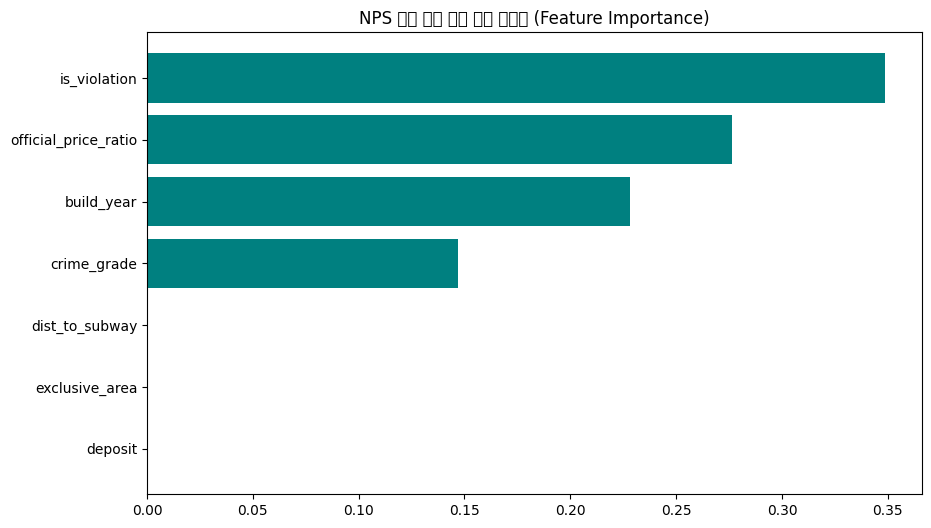

📌 분석 결과 요약:
가장 영향력이 큰 변수는 'is_violation' 입니다.


In [4]:
# 6. 피처 중요도 분석 (어떤 변수가 NPS를 결정짓는가?)
feature_importance = gb_model.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + .5

plt.figure(figsize=(10, 6))
plt.barh(pos, feature_importance[sorted_idx], align='center', color='teal')
plt.yticks(pos, np.array(X.columns)[sorted_idx])
plt.title('NPS 안심 점수 결정 피처 중요도 (Feature Importance)')
plt.show()

print("📌 분석 결과 요약:")
print(f"가장 영향력이 큰 변수는 '{X.columns[np.argmax(feature_importance)]}' 입니다.")